Jupyter Notebook for the Kaggle Competition (Machine Learning - CentraleSupélec - January 2025)  
PAES DE ALMEIDA NINA DUARTE, Pedro ; COLLIER, Grégoire ; PERARDT MAGALHÃES BRITO, Romero

Import necessary packages

In [1]:
import geopandas as gpd
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np


from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

Import data (as shown in the baseline code) and treat NaN

In [61]:
change_type_map = {'Demolition': 0, 'Road': 1, 'Residential': 2, 'Commercial': 3, 'Industrial': 4,
                   'Mega Projects': 5}

## Read csvs

train_df = gpd.read_file('../train.geojson', index_col=0)
test_df = gpd.read_file('../test.geojson', index_col=0)

train_y = train_df['change_type'].apply(lambda x: change_type_map[x])

submission_df = pd.DataFrame(test_df['index'])

c:\Users\romer\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option INDEX_COL
  return ogr_read(
c:\Users\romer\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\array.py:334: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  self.crs = crs
c:\Users\romer\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:409: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  level.crs = crs
c:\Users\romer\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: Runti

Fill NaN with mean

In [3]:
ignore_columns = ['urban_type', 'geography_type', 'change_type','date0', 'change_status_date0', 'date1',
                   'change_status_date1','date2', 'change_status_date2','date3', 'change_status_date3', 
                   'date4', 'change_status_date4', 'index', 'geometry']

for col in train_df.columns:
    if col not in ignore_columns:
        train_df[col].fillna(train_df[col].mean(), inplace=True)

C:\Users\romer\AppData\Local\Temp\ipykernel_8988\2416107534.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)


Fill missing dates with closest date (one above)

In [4]:
train_df['date0'].fillna(method='ffill', inplace=True)
train_df['date1'].fillna(method='ffill', inplace=True)
train_df['date2'].fillna(method='ffill', inplace=True)
train_df['date3'].fillna(method='ffill', inplace=True)
train_df['date4'].fillna(method='ffill', inplace=True)

C:\Users\romer\AppData\Local\Temp\ipykernel_8988\4175239564.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['date0'].fillna(method='ffill', inplace=True)
C:\Users\romer\AppData\Local\Temp\ipykernel_8988\4175239564.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df['date0'].fillna(method='ffill', inplace=True)
C:\Users\romer\AppData\Local\Temp\ipykernel_8988\4175239564.py:2: FutureWarning: A value is trying to be set 

Treat 'N,A' in 'urban_type' and 'geography_type' column

In [6]:
""" ## Used codes for urban_type and geography_type
train_df[train_df['urban_type'] == 'N,A']
train_df[train_df['geography_type'].str.contains('Snow')]['urban_type'].value_counts()
train_df['urban_type'].value_counts()  """

" ## Used codes for urban_type and geography_type\ntrain_df[train_df['urban_type'] == 'N,A']\ntrain_df[train_df['geography_type'].str.contains('Snow')]['urban_type'].value_counts()\ntrain_df['urban_type'].value_counts()  "

In [5]:
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Dense Forest|Farms"))), 'urban_type'] = 'Rural'
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Barren Land"))), 'urban_type'] = 'Urban'
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Sparse Forest"))), 'urban_type'] = 'Sparse Urban'


## Costal had 3545 N,A, 136 Industrial, 32 Sparse Urban and 19 Dense Urban
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Coastal"))), 'urban_type'] = 'Industrial'

## River had 664 Industrial, 215 Dense Urban and 115 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("River"))), 'urban_type'] = 'Industrial'

## Desert had 1520 N,A, 1350 Industrial, 1257 Sparse Urban and 940 Dense Urban
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Desert"))), 'urban_type'] = 'Industrial'

## Lakes or Green Land had 15669 Sparse Urban and 237 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Lakes|Green Land"))), 'urban_type'] = 'Sparse Urban'

## Grass Land had 41861 Dense Urban, 33048 Sparse Urban and 271 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Grass Land"))), 'urban_type'] = 'Dense Urban'

## Snow had 4 Sparse Urban, 3 Dense Urban and 3 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Snow"))), 'urban_type'] = 'Sparse Urban'

In [6]:
## Unideal substitution
train_df.loc[train_df['geography_type'] == 'N,A', 'geography_type'] = 'Sparse Forest'
train_df.loc[train_df['geography_type'] == None, 'geography_type'] = 'Sparse Urban'

In [7]:
from datetime import datetime
date_format = "%d-%m-%Y"

for column in ['date0', 'date1', 'date2', 'date3', 'date4']:
    train_df[column] = train_df[column].apply(lambda x: datetime.strptime(x,date_format))

In [8]:
# Specify the columns that should be sorted (col1 to col8 in this case)
cols_to_sort = ['date0','change_status_date0','date1','change_status_date1','date2','change_status_date2','date3','change_status_date3', 'date4','change_status_date4']


# Function to sort only the selected columns
def sort_selected_columns_numpy(row):
    num_values = np.array(row[cols_to_sort[::2]])  # Extract numeric values
    str_values = np.array(row[cols_to_sort[1::2]])  # Extract paired strings
    sorted_indices = np.argsort(num_values)  # Get sorting order
    
    # Rearrange both numeric and string values based on sorted indices
    sorted_nums = num_values[sorted_indices]
    sorted_strs = str_values[sorted_indices]
    
    # Flatten and reassign the sorted values back to the row
    row[cols_to_sort] = np.column_stack((sorted_nums, sorted_strs)).flatten()
    return row

# Apply function row-wise
train_df = train_df.apply(sort_selected_columns_numpy, axis=1)


Start encoding the categorical labels


In [9]:
urban_types = list(train_df['urban_type'].unique())
unique_urban_types = []
for type in urban_types:
    #print(type, type.split(','))
    unique_urban_types += type.split(',')
unique_urban_types = set(unique_urban_types)
#print(unique_urban_types)

geo_types = list(train_df['geography_type'].unique())
unique_geo_types = []
for type in geo_types:
    #print(type, type.split(','))
    unique_geo_types += type.split(',')
unique_geo_types = set(unique_geo_types)
#print(unique_geo_types)

train_df['urban_type'] = train_df['urban_type'].apply(lambda x: x.split(','))
train_df['geography_type'] = train_df['geography_type'].apply(lambda x: x.split(','))

for unique_geo_type in unique_geo_types:
    train_df[unique_geo_type] = train_df['geography_type'].apply(lambda x: 1 if unique_geo_type in x else 0)
for unique_urban_type in unique_urban_types:
    train_df[unique_urban_type] = train_df['urban_type'].apply(lambda x: 1 if unique_urban_type in x else 0)

In [10]:

status = []
for column in ['change_status_date0', 'change_status_date1', 'change_status_date2', 'change_status_date3', 'change_status_date4']:
    status += list(train_df[column].unique())
status = set(status)
""" for element in status:
    print(element) """

change_status_map = {'Materials Dumped': 2, 'Construction Done': 7, 'Construction Midway':6, 'Construction Started': 5, 'Greenland': 0, 'Prior Construction': 9,
                   'Land Cleared': 1,'Materials Introduced':4, 'Excavation': 3,'Operational': 8, None: 4.5}

train_df['change_status_date0'] = train_df['change_status_date0'].apply(lambda x: change_status_map[x])
train_df['change_status_date1'] = train_df['change_status_date1'].apply(lambda x: change_status_map[x])
train_df['change_status_date2'] = train_df['change_status_date2'].apply(lambda x: change_status_map[x])
train_df['change_status_date3'] = train_df['change_status_date3'].apply(lambda x: change_status_map[x])
train_df['change_status_date4'] = train_df['change_status_date4'].apply(lambda x: change_status_map[x])

In [11]:
train_df['area'] = train_df['geometry'].area
train_df['length'] = train_df['geometry'].length
train_df['n_edges'] = train_df['geometry'].apply(lambda x: len(x.exterior.coords)-1)
train_df.drop('geometry', axis = 1, inplace=True)

In [12]:
time_diffs = ['time_diff_1','time_diff_2','time_diff_3', 'time_diff_4']
dates = ['date0', 'date1', 'date2', 'date3', 'date4']
for i in range(4):
    train_df[time_diffs[i]] = train_df[dates[i+1]] - train_df[dates[i]]
    train_df[time_diffs[i]] = train_df[time_diffs[i]].apply(lambda x: x.days)

In [13]:
train_df.drop(dates, axis=1, inplace = True)
preprocessed_df = train_df.drop(['urban_type', 'geography_type', 'change_type', 'index'], axis=1)

In [34]:
preprocessed_df.drop(['img_red_mean_date1', 'img_green_mean_date1', 'img_blue_mean_date1',
       'img_red_std_date1', 'img_green_std_date1', 'img_blue_std_date1',
       'img_red_mean_date2', 'img_green_mean_date2', 'img_blue_mean_date2',
       'img_red_std_date2', 'img_green_std_date2', 'img_blue_std_date2',
       'img_red_mean_date3', 'img_green_mean_date3', 'img_blue_mean_date3',
       'img_red_std_date3', 'img_green_std_date3', 'img_blue_std_date3',
       'img_red_mean_date4', 'img_green_mean_date4', 'img_blue_mean_date4',
       'img_red_std_date4', 'img_green_std_date4', 'img_blue_std_date4',
       'img_red_mean_date5', 'img_green_mean_date5', 'img_blue_mean_date5',
       'img_red_std_date5', 'img_green_std_date5', 'img_blue_std_date5'], axis=1, inplace = True)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

X_train, X_test, y_train, y_test = train_test_split(preprocessed_df, train_y, train_size=0.8, random_state = 0)

from sklearn.tree import DecisionTreeClassifier
dtree_model = DecisionTreeClassifier(max_depth = 30).fit(X_train, y_train)
dtree_predictions = dtree_model.predict(X_test)

# creating a confusion matrix
cm = confusion_matrix(y_test, dtree_predictions)

accuracy = accuracy_score(y_pred=dtree_predictions, y_true=y_test)
score = f1_score(y_test, dtree_predictions, average = 'macro')
cm

array([[ 4532,    35,  1052,   520,    10,     5],
       [   32,  1518,   523,   868,    14,     5],
       [ 1039,   435, 21740,  6324,   100,     7],
       [  578,   863,  6766, 11833,   127,    12],
       [   12,    11,    88,   125,    29,     0],
       [    1,     1,    12,    11,     1,     1]], dtype=int64)

In [45]:
accuracy

0.6694749282458213

In [46]:
score

0.45287398613328134

Replicate steps above for test set

In [50]:
def pipeline(train_df):
    for col in train_df.columns:
        if col not in ignore_columns:
            train_df[col].fillna(train_df[col].mean(), inplace=True)

    train_df['date0'].fillna(method='ffill', inplace=True)
    train_df['date1'].fillna(method='ffill', inplace=True)
    train_df['date2'].fillna(method='ffill', inplace=True)
    train_df['date3'].fillna(method='ffill', inplace=True)
    train_df['date4'].fillna(method='ffill', inplace=True)

    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Dense Forest|Farms"))), 'urban_type'] = 'Rural'
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Barren Land"))), 'urban_type'] = 'Urban'
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Sparse Forest"))), 'urban_type'] = 'Sparse Urban'


    ## Costal had 3545 N,A, 136 Industrial, 32 Sparse Urban and 19 Dense Urban
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Coastal"))), 'urban_type'] = 'Industrial'

    ## River had 664 Industrial, 215 Dense Urban and 115 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("River"))), 'urban_type'] = 'Industrial'

    ## Desert had 1520 N,A, 1350 Industrial, 1257 Sparse Urban and 940 Dense Urban
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Desert"))), 'urban_type'] = 'Industrial'

    ## Lakes or Green Land had 15669 Sparse Urban and 237 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Lakes|Green Land"))), 'urban_type'] = 'Sparse Urban'

    ## Grass Land had 41861 Dense Urban, 33048 Sparse Urban and 271 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Grass Land"))), 'urban_type'] = 'Dense Urban'

    ## Snow had 4 Sparse Urban, 3 Dense Urban and 3 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Snow"))), 'urban_type'] = 'Sparse Urban'

    ## Unideal substitution
    train_df.loc[train_df['geography_type'] == 'N,A', 'geography_type'] = 'Sparse Forest'
    train_df.loc[train_df['geography_type'] == None, 'geography_type'] = 'Sparse Urban'

    date_format = "%d-%m-%Y"

    for column in ['date0', 'date1', 'date2', 'date3', 'date4']:
        train_df[column] = train_df[column].apply(lambda x: datetime.strptime(x,date_format))
    # Specify the columns that should be sorted (col1 to col8 in this case)
    cols_to_sort = ['date0','change_status_date0','date1','change_status_date1','date2','change_status_date2','date3','change_status_date3', 'date4','change_status_date4']


    # Function to sort only the selected columns
    def sort_selected_columns_numpy(row):
        num_values = np.array(row[cols_to_sort[::2]])  # Extract numeric values
        str_values = np.array(row[cols_to_sort[1::2]])  # Extract paired strings
        sorted_indices = np.argsort(num_values)  # Get sorting order
        
        # Rearrange both numeric and string values based on sorted indices
        sorted_nums = num_values[sorted_indices]
        sorted_strs = str_values[sorted_indices]
        
        # Flatten and reassign the sorted values back to the row
        row[cols_to_sort] = np.column_stack((sorted_nums, sorted_strs)).flatten()
        return row

    # Apply function row-wise
    train_df = train_df.apply(sort_selected_columns_numpy, axis=1)
    
    train_df.drop('index', axis = 1, inplace=True)
    urban_types = list(train_df['urban_type'].unique())
    unique_urban_types = []
    for type in urban_types:
        #print(type, type.split(','))
        unique_urban_types += type.split(',')
    unique_urban_types = set(unique_urban_types)
    #print(unique_urban_types)

    geo_types = list(train_df['geography_type'].unique())
    unique_geo_types = []
    for type in geo_types:
        #print(type, type.split(','))
        unique_geo_types += type.split(',')
    unique_geo_types = set(unique_geo_types)
    #print(unique_geo_types)
    
    train_df['urban_type'] = train_df['urban_type'].apply(lambda x: x.split(','))
    train_df['geography_type'] = train_df['geography_type'].apply(lambda x: x.split(','))

    for unique_geo_type in unique_geo_types:
        train_df[unique_geo_type] = train_df['geography_type'].apply(lambda x: 1 if unique_geo_type in x else 0)
    for unique_urban_type in unique_urban_types:
        train_df[unique_urban_type] = train_df['urban_type'].apply(lambda x: 1 if unique_urban_type in x else 0)


    change_status_map = {'Materials Dumped': 2, 'Construction Done': 7, 'Construction Midway':6, 'Construction Started': 5, 'Greenland': 0, 'Prior Construction': 9,
                    'Land Cleared': 1,'Materials Introduced':4, 'Excavation': 3,'Operational': 8, None: 4.5}

    train_df['change_status_date0'] = train_df['change_status_date0'].apply(lambda x: change_status_map[x])
    train_df['change_status_date1'] = train_df['change_status_date1'].apply(lambda x: change_status_map[x])
    train_df['change_status_date2'] = train_df['change_status_date2'].apply(lambda x: change_status_map[x])
    train_df['change_status_date3'] = train_df['change_status_date3'].apply(lambda x: change_status_map[x])
    train_df['change_status_date4'] = train_df['change_status_date4'].apply(lambda x: change_status_map[x])

    train_df['area'] = train_df['geometry'].area
    train_df['length'] = train_df['geometry'].length
    train_df['n_edges'] = train_df['geometry'].apply(lambda x: len(x.exterior.coords)-1)

    train_df.drop('geometry', axis = 1, inplace=True)


    time_diffs = ['time_diff_1','time_diff_2','time_diff_3', 'time_diff_4']
    dates = ['date0', 'date1', 'date2', 'date3', 'date4']
    for i in range(4):
        train_df[time_diffs[i]] = train_df[dates[i+1]] - train_df[dates[i]]
        train_df[time_diffs[i]] = train_df[time_diffs[i]].apply(lambda x: x.days)


    preprocessed_df = train_df.drop(dates, axis=1)
    preprocessed_df = preprocessed_df.drop(['urban_type', 'geography_type'], axis=1)

    return preprocessed_df

preprocessed_test_df = pipeline(test_df)
#preprocessed_test_df

C:\Users\romer\AppData\Local\Temp\ipykernel_8988\3993924143.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)
C:\Users\romer\AppData\Local\Temp\ipykernel_8988\3993924143.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [51]:
preprocessed_test_df.drop(['img_red_mean_date1', 'img_green_mean_date1', 'img_blue_mean_date1',
       'img_red_std_date1', 'img_green_std_date1', 'img_blue_std_date1',
       'img_red_mean_date2', 'img_green_mean_date2', 'img_blue_mean_date2',
       'img_red_std_date2', 'img_green_std_date2', 'img_blue_std_date2',
       'img_red_mean_date3', 'img_green_mean_date3', 'img_blue_mean_date3',
       'img_red_std_date3', 'img_green_std_date3', 'img_blue_std_date3',
       'img_red_mean_date4', 'img_green_mean_date4', 'img_blue_mean_date4',
       'img_red_std_date4', 'img_green_std_date4', 'img_blue_std_date4',
       'img_red_mean_date5', 'img_green_mean_date5', 'img_blue_mean_date5',
       'img_red_std_date5', 'img_green_std_date5', 'img_blue_std_date5'], axis=1, inplace = True)

In [52]:
preprocessed_test_df.shape

preprocessed_test_df = preprocessed_test_df[preprocessed_df.columns]

In [53]:
dtree_predictions_kaggle = dtree_model.predict(preprocessed_test_df)
dtree_predictions_kaggle

array([3, 2, 2, ..., 1, 2, 2], dtype=int64)

In [54]:
submission_df['change_type'] = dtree_predictions_kaggle
submission_df

,index,change_type
0,0,3
1,1,2
2,2,2
3,3,2
4,4,0
...,...,...
120521,120521,3
120522,120522,1
120523,120523,1
120524,120524,2


In [57]:
submission_df = submission_df.rename(columns={'index': 'Id', 'change_type': 'change_type'})
submission_df

,Id,change_type
0,0,3
1,1,2
2,2,2
3,3,2
4,4,0
...,...,...
120521,120521,3
120522,120522,1
120523,120523,1
120524,120524,2


Create csv for submission

In [58]:
from pathlib import Path  
filepath = Path('./submission.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

New model w/ OneVsRest + SVC

In [30]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(preprocessed_df, train_y, train_size=0.3, random_state = 0)

model = OneVsRestClassifier(LinearSVC(random_state=0)).fit(X_train, y_train)
predictions = model.predict(X_test)

# creating a confusion matrix
cm = confusion_matrix(y_test, predictions)


accuracy = accuracy_score(y_test, predictions)
score = f1_score(y_test, predictions, average = 'macro')
cm

array([[19467,     0,  1434,  1158,     0,     0],
       [   62,    35,  7046,  2977,     0,     0],
       [ 4179,    11, 84415, 15299,     0,     0],
       [ 1945,    22, 39172, 29067,     0,     0],
       [   31,     1,   536,   339,     0,     0],
       [    4,     3,    67,    33,     0,     0]], dtype=int64)

In [31]:
accuracy

0.6414957815371702

In [32]:
score

0.3373556043829417

PyTorch Model

In [59]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [60]:
X_data = preprocessed_df.to_numpy()
y_data = train_y.to_numpy()
X_final_test = preprocessed_test_df.to_numpy()

X_data = torch.from_numpy(X_data).type(torch.float)
y_data = torch.from_numpy(y_data).type(torch.float)
X_final_test = torch.from_numpy(X_final_test).type(torch.float)

In [35]:
X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(X_data, y_data, test_size=0.30, random_state=101)

In [36]:
model_pt = nn.Sequential(
    nn.Linear(in_features=X_train_pt.shape[1], out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=256),
    nn.ReLU(),
    #nn.Linear(in_features=256, out_features=512),
    #nn.ReLU(),
    #nn.Linear(in_features=512, out_features=1024),
    #nn.ReLU(),
    nn.Linear(in_features=256, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=6)
    )

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_pt.parameters(),
                            lr = 0.0001)

In [37]:
from torcheval.metrics.functional import multiclass_f1_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [38]:
y_train_pt = y_train_pt.type(torch.LongTensor)
y_test_pt = y_test_pt.type(torch.LongTensor)

In [39]:
epochs = 100
train_loss = []
test_loss = []
epoch_count = []

for epoch in range(epochs):
    epoch_count.append(epoch)

    ### Train model

    model_pt.train()

    #y_pred_train = torch.round(torch.sigmoid(model_pt(X_train_pt)))
    y_pred_train = model_pt(X_train_pt)

    loss = loss_fn(y_pred_train, y_train_pt)

    train_loss.append(loss)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Evalualte model

    model_pt.eval()

    with torch.inference_mode():
        y_pred_test = model_pt(X_test_pt)

    loss_test = loss_fn(y_pred_test, y_test_pt)
    test_loss.append(loss_test)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} ||| train loss {loss} ||| test loss {loss_test}")

Epoch 0 ||| train loss 1.288621187210083 ||| test loss 1.4288554191589355
Epoch 10 ||| train loss 1.1458733081817627 ||| test loss 1.1393829584121704
Epoch 20 ||| train loss 1.1095001697540283 ||| test loss 1.1122679710388184
Epoch 30 ||| train loss 1.0884184837341309 ||| test loss 1.084168553352356
Epoch 40 ||| train loss 1.0697729587554932 ||| test loss 1.0670385360717773
Epoch 50 ||| train loss 1.0542482137680054 ||| test loss 1.0520167350769043
Epoch 60 ||| train loss 1.041325330734253 ||| test loss 1.0393222570419312
Epoch 70 ||| train loss 1.0278403759002686 ||| test loss 1.0264878273010254
Epoch 80 ||| train loss 1.014489769935608 ||| test loss 1.0134752988815308
Epoch 90 ||| train loss 1.0009187459945679 ||| test loss 1.0004291534423828


In [40]:
import matplotlib.pyplot as plt

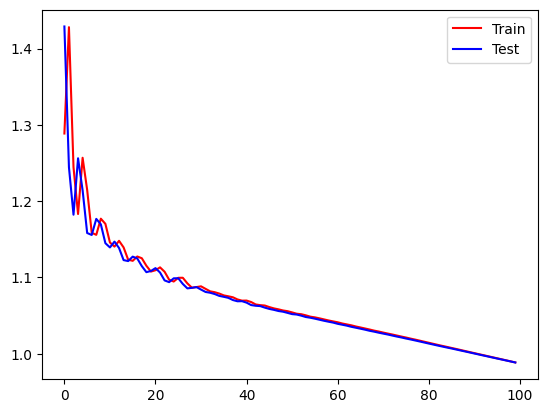

In [41]:
plt.plot(epoch_count, np.array(torch.tensor(train_loss).numpy()), label='Train', c='r')
plt.plot(epoch_count, np.array(torch.tensor(test_loss).numpy()), label='Test', c='b')
plt.legend()
plt.show()

In [42]:
predictions = model_pt(X_test_pt)

# creating a confusion matrix
cm = confusion_matrix(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))

accuracy = accuracy_score(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))
score = f1_score(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()), average = 'macro')
cm

C:\Users\pedro\AppData\Local\Temp\ipykernel_22752\456158572.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cm = confusion_matrix(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))
C:\Users\pedro\AppData\Local\Temp\ipykernel_22752\456158572.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  accuracy = accuracy_score(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))
C:\Users\pedro\AppData\Local\Temp\ipykernel_22752\456158572.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scor

array([[ 1560,     0,  5564,  2289,     0,     0],
       [  117,     3,  2635,  1527,     0,     0],
       [  434,     0, 35998,  8075,     0,     0],
       [  329,     3, 16162, 13705,     0,     0],
       [    2,     0,   239,   158,     0,     0],
       [    0,     0,    34,    10,     0,     0]], dtype=int64)

In [43]:
accuracy

0.5770339021205709

In [44]:
score

0.23985615465625187

In [45]:
submit_predictions_nn = np.array(torch.tensor(torch.argmax(model_pt(X_final_test), axis=1)).numpy())

submission_df_nn = pd.DataFrame(submit_predictions_nn, columns=['change_type'])
submission_df_nn.insert(0, 'Id', submission_df['Id'])
submission_df_nn

C:\Users\pedro\AppData\Local\Temp\ipykernel_22752\184501322.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  submit_predictions_nn = np.array(torch.tensor(torch.argmax(model_pt(X_final_test), axis=1)).numpy())


,Id,change_type
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2
...,...,...
120521,120521,2
120522,120522,2
120523,120523,2
120524,120524,2


In [46]:
from pathlib import Path  
filepath = Path('./submission_nn.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df_nn.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

AdaBoost

In [47]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the base estimator
base_estimator = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=8)
    # Initialize the AdaBoost classifier with the base estimator
ada_clf = AdaBoostClassifier(estimator=base_estimator, n_estimators=300, random_state=42)
# Train the classifier
ada_clf.fit(X_train, y_train)
# Make predictions on the test set
y_pred = ada_clf.predict(X_test)
# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
score = f1_score(y_test, y_pred, average = 'macro')
print(f"Accuracy: {accuracy:.2f}, Score: {score:.2f}")

c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.54, Score: 0.35


In [48]:
submit_pred_adaboost = ada_clf.predict(preprocessed_test_df)
submission_df_adaboost = pd.DataFrame(submit_pred_adaboost, columns=['change_type'])
submission_df_adaboost.insert(0, 'Id', submission_df['Id'])
submission_df_adaboost

,Id,change_type
0,0,3
1,1,2
2,2,2
3,3,1
4,4,0
...,...,...
120521,120521,1
120522,120522,3
120523,120523,2
120524,120524,2


In [49]:
from pathlib import Path
filepath = Path('./submission_adaboost.csv')
filepath.parent.mkdir(parents=True, exist_ok=True)
submission_df_adaboost.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

In [50]:
train_y

0         1
1         1
2         1
3         1
4         0
         ..
296141    3
296142    2
296143    2
296144    2
296145    2
Name: change_type, Length: 296146, dtype: int64

Imbalanced classes

(array([ 31509.,  14305., 148435., 100422.,   1324.,    151.]),
 array([0., 1., 2., 3., 4., 5., 6.]),
 <BarContainer object of 6 artists>)

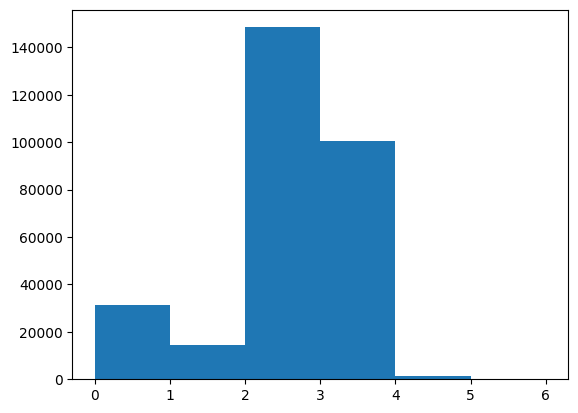

In [51]:
plt.hist(train_y, bins=[0,1,2,3,4,5,6])

In [53]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.metrics import accuracy_score, classification_report


# Create a Random Forest Classifier (you can use any classifier)
base_classifier = RandomForestClassifier(random_state=42)


# Create a BalancedBaggingClassifier
balanced_bagging_classifier = BalancedBaggingClassifier(base_classifier,
														sampling_strategy='auto', # You can adjust this parameter
														replacement=False, # Whether to sample with or without replacement
														random_state=42)

# Fit the model
balanced_bagging_classifier.fit(X_train, y_train)

# Make predictions
y_pred = balanced_bagging_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
score = f1_score(y_test, y_pred, average='macro')

print(f"acc: {accuracy} || f1: {score}")

acc: 0.5201420143461504 || f1: 0.368804913228219


SMOTE

In [62]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
score = f1_score(y_test, y_pred, average='macro')
print(f"Accuracy: {accuracy} || F1: {score}")

Accuracy: 0.7321939383414615 || F1: 0.5044209991286247


In [63]:
submit_pred_rf = rf.predict(preprocessed_test_df)
submission_df_rf = pd.DataFrame(submit_pred_rf, columns=['change_type'])
submission_df_rf.insert(0, 'Id', submission_df['Id'])

In [64]:
from pathlib import Path
filepath = Path('./submission_rf.csv')
filepath.parent.mkdir(parents=True, exist_ok=True)
submission_df_rf.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

Tuning Decision Tree HyperParameters

In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
# Define the model
model_tune = DecisionTreeClassifier()

# Define the grid of parameters
param_grid = {'max_depth': [3, 5, 7, 9]}

# Apply GridSearchCV
grid_search = GridSearchCV(model_tune, param_grid, cv=5)
grid_search.fit(X_train_resampled, y_train_resampled)

print(grid_search.best_params_)

{'max_depth': 9}


In [57]:
# Define the grid of parameters
param_grid = {'min_samples_split': [2, 5, 10]}

# Apply GridSearchCV
grid_search = GridSearchCV(model_tune, param_grid, cv=5)
grid_search.fit(X_train_resampled, y_train_resampled)

print(grid_search.best_params_)

{'min_samples_split': 2}


In [58]:
# Define the grid of parameters
param_grid = {'min_samples_leaf': [1, 2, 4]}

# Apply GridSearchCV
grid_search = GridSearchCV(model_tune, param_grid, cv=5)
grid_search.fit(X_train_resampled, y_train_resampled)

print(grid_search.best_params_)

{'min_samples_leaf': 1}


In [59]:
# Define the grid of parameters
param_grid = {'max_features': [2, 3, 4]}

# Apply GridSearchCV
grid_search = GridSearchCV(model_tune, param_grid, cv=5)
grid_search.fit(X_train_resampled, y_train_resampled)

print(grid_search.best_params_)

{'max_features': 4}


In [60]:
# Define the grid of parameters
param_grid = {'criterion': ['gini', 'entropy']}

# Apply GridSearchCV
grid_search = GridSearchCV(model_tune, param_grid, cv=5)
grid_search.fit(X_train_resampled, y_train_resampled)

print(grid_search.best_params_)

{'criterion': 'entropy'}


Final tuned RF

In [61]:
rf_tune = RandomForestClassifier(max_depth=9, min_samples_split=2, min_samples_leaf=1, max_features=4, criterion='entropy')
rf_tune.fit(X_train_resampled, y_train_resampled)

y_pred = rf_tune.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
score = f1_score(y_test, y_pred, average='macro')
print(f"Accuracy: {accuracy} || F1: {score}")

Accuracy: 0.604366555235573 || F1: 0.4032287899219586
